<center> <img src="https://miro.medium.com/v2/resize:fit:1200/1*lbDXL0IuitCRz4mpZ7MmfQ.png" width=55% > </center>

<br><br>

<center> 
    <font size="6">Final Lab (Part 2): Image Classification using Convolutional Neural Networks </font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, 24th October, 2025 (Amsterdam time)</font> 
</center>

<br><br>

***

<br><br>

<center>

Student1 ID:  \
Student1 Name: 

Student2 ID: \
Student2 Name: 

Student3 ID: \
Student3 Name: 

( Student4 ID: \
Student4 Name: )

</center>

### **Coding Guidelines**

Your code must be handed in this Jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Final Lab: Image Classification Assignment. Please also fill out your names and IDs above.

For full credit, make sure your notebook follows these guidelines:

- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Understand the problem as much as you can. When answering a question, provide evidence (qualitative and/or quantitative results, references to papers, figures, etc.) to support your arguments. Not everything might be explicitly asked for, so think about what might strengthen your arguments to make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Add a number, a title, and, if applicable, the name and unit of variables in a table, and name and unit of axes and legends in a figure.

**Late submissions are not allowed.** Assignments submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance to avoid last-minute system failure issues.

**Environment:** Since this is a project-based assignment, you are free to use any feature descriptor and machine learning tools (e.g., K-means, SVM). You should use Python for your implementation. You are free to use any Python library for this assignment, but make sure to provide a conda environment file!

**Plagiarism Note:** Keep in mind that plagiarism (submitted materials which are not your work) is a serious offense and any misconduct will be addressed according to university regulations. This includes using generative tools such as ChatGPT.

**Ensure that you save all results/answers to the questions (even if you reuse some code).**

### **Report Preparation**

Your tasks include the following:

1. **Report Preparation:** For both parts of the final project, students are expected to prepare a report. The report should include all details on implementation approaches, analysis of results for different settings, and visualizations illustrating experiments and performance of your implementation. Grading will be based on the report, so it should be as self-contained as possible. If the report contains faulty results or ambiguities, TAs can refer to your code for clarification. 

2. **Explanation of Results:** Do not just provide numbers without explanation. Discuss different settings to show your understanding of the material and processes involved.

3. **Quantitative Evaluation:** For quantitative evaluation, you are expected to provide the results based on performance (accuracy, learning loss and learning curves). 

4. **Aim:** Understand the basic Image Classification pipeline using Convolutional Neural Nets (CNN's).

5. **Working on Assignments:** Students should work in assigned groups for **two** weeks. Any questions can be discussed on ED.

    - **Submission:** Submit your source code and report together in a zip file (`ID1_ID2_ID3_part2.zip`). The report should be a maximum of 10 pages (single-column, including tables and figures, excluding references and appendix). Express thoughts concisely. Tables and figures must be accompanied by a description. Number them and, if applicable, name variables in tables, and label axes in figures.

6. **Hyperparameter Search:** In your experiments, remember to perform a hyperparameter search to find the optimal settings for your model(s). Clearly document the search process, the parameters you explored, and how they influenced the performance of your model.

8. **Format and Testing:** The report should be in **PDF format**, and the code in **.ipynb format**. Test that all functionality works as expected in the notebook.

### **Overview**

- [Section 1: Image Classification on CIFAR-100 (0 points)](#section-1)
- [Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)](#section-2)
- [Section 3: TwoLayerNet Architecture (2 points)](#section-3)
- [Section 4: ConvNet Architecture (2 points)](#section-4)
- [Section 5: Preparation of Training (7 points)](#section-5)
- [Section 6: Training the Networks (5 points)](#section-6)
- [Section 7: Setting Up the Hyperparameters (14 points)](#section-7)
- [Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)](#section-8)
- [Section 9: Fine-tuning ConvNet on STL-10 (14 points)](#section-9)
- [Section 10: Bonus Challenge (optional)](#section-10)
- [Section X: Individual Contribution Report (Mandatory)](#section-x)

### **Section 1: Image Classification on CIFAR-100 (0 points)**

The goal of this lab is to implement an image classification system using Convolutional Neural Networks (CNNs) that can identify objects from a set of classes in the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). You will implement and compare two different architectures: a simple two-layer network and a ConvNet based on the LeNet architecture.

The CIFAR-100 dataset contains 32x32 pixel RGB images, categorized into 100 different classes. The dataset will be automatically downloaded and loaded using the code provided in this notebook.

You will train and test your classification system using the entire CIFAR-100 dataset. Ensure that the test images are excluded from training to maintain a fair evaluation of the model's performance.

In [1]:
import os
from pathlib import Path
from datetime import datetime
import random
import math
import json

## pytorch library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision import datasets as tv_datasets
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset, random_split
from torch.utils.tensorboard import SummaryWriter

## we add some libraries

## data processing
import numpy as np
import pandas as pd

## visualization
import plotly.express as px
import matplotlib.pyplot as plt
from PIL import Image


## higher quality figure output
%config InlineBackend.figure_format = 'svg'

## Machine Learning library
import sklearn as skl

## hyperparameter tuning
import optuna


####################################################################################

# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

# Load the CIFAR-100 training set
train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Load the CIFAR-100 test set
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Create data loaders for the entire CIFAR-100 dataset
train_data_loader = DataLoader(train_set, shuffle=True)
test_data_loader = DataLoader(test_set, shuffle=False)

# Define CIFAR-100 superclasses and their subclasses
superclasses = {
    'aquatic mammals': ['beaver', 'dolphin', 'otter', 'seal', 'whale'],
    'fish': ['aquarium_fish', 'flatfish', 'ray', 'shark', 'trout'],
    'flowers': ['orchid', 'poppy', 'rose', 'sunflower', 'tulip'],
    'food containers': ['bottle', 'bowl', 'can', 'cup', 'plate'],
    'fruit and vegetables': ['apple', 'mushroom', 'orange', 'pear', 'sweet_pepper'],
    'household electrical devices': ['clock', 'keyboard', 'lamp', 'telephone', 'television'],
    'household furniture': ['bed', 'chair', 'couch', 'table', 'wardrobe'],
    'insects': ['bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'],
    'large carnivores': ['bear', 'leopard', 'lion', 'tiger', 'wolf'],
    'large man-made outdoor things': ['bridge', 'castle', 'house', 'road', 'skyscraper'],
    'large natural outdoor scenes': ['cloud', 'forest', 'mountain', 'plain', 'sea'],
    'large omnivores and herbivores': ['camel', 'cattle', 'chimpanzee', 'elephant', 'kangaroo'],
    'medium-sized mammals': ['fox', 'porcupine', 'possum', 'raccoon', 'skunk'],
    'non-insect invertebrates': ['crab', 'lobster', 'snail', 'spider', 'worm'],
    'people': ['baby', 'boy', 'girl', 'man', 'woman'],
    'reptiles': ['crocodile', 'dinosaur', 'lizard', 'snake', 'turtle'],
    'small mammals': ['hamster', 'mouse', 'rabbit', 'shrew', 'squirrel'],
    'trees': ['maple_tree', 'oak_tree', 'palm_tree', 'pine_tree', 'willow_tree'],
    'vehicles 1': ['bicycle', 'bus', 'motorcycle', 'pickup_truck', 'train'],
    'vehicles 2': ['lawn_mower', 'rocket', 'streetcar', 'tank', 'tractor']
}

# List of all CIFAR-100 classes
classes = ('apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 
           'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
           'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
           'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
           'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
           'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
           'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
           'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 
           'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 
           'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm')

# Create a mapping of class names to their indices
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

# Create a mapping of superclasses to their corresponding class indices
superclass_to_indices = {supcls: [class_to_idx[cls] for cls in subclasses] for supcls, subclasses in superclasses.items()}

print("Data loaders for CIFAR-100 are ready for use.")

Files already downloaded and verified
Files already downloaded and verified
Data loaders for CIFAR-100 are ready for use.


In [2]:
## save random image from dataset
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title('Sample images')
    plt.savefig('samples.svg')
    plt.show()

<a id="section-2"></a>
### **Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)**

In this section, you will implement a function to visualize the CIFAR-100 dataset, including **all** superclasses and their corresponding subclasses. Your implementation should provide a clear and organized overview of the dataset's diversity.

You add the figure(s) to appendix of your report and refer to it in the main text.

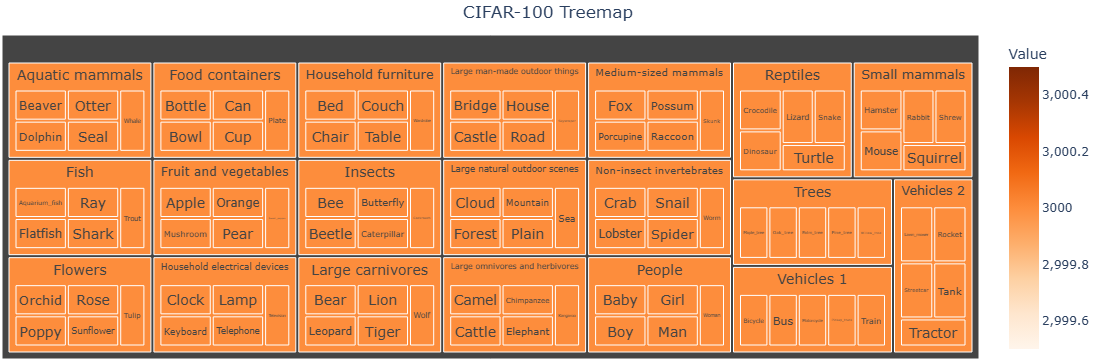

<Figure size 640x480 with 0 Axes>

In [5]:
# YOUR CODE HERE
## define a function to visualize CIFAR_100 dataset

def visualize_sub_super(superclasses, train_set, test_set, classes):
    """
    superclasses: dict[superclass -> list of subclass names]
    train_set, test_set: iterable of (image, label_index)
    classes: list of CIFAR-100 class names in label index order
    """

    # Map label index (superclasses and their subclasses)
    label_to_super = {}
    for sup, subs in superclasses.items():
        for sub in subs:
            idx = classes.index(sub)  
            label_to_super[idx] = sup

    # Initialize the counters in train and test set
    train_counts = {sup: 0 for sup in superclasses}
    test_counts  = {sup: 0 for sup in superclasses}

    # Count the number of samples in the train and test set
    for _, label in train_set:
        sup = label_to_super.get(label)
        if sup is not None:
            train_counts[sup] += 1

    for _, label in test_set:
        sup = label_to_super.get(label)
        if sup is not None:
            test_counts[sup] += 1

    # Create a DataFrame
    ## First we build the rows for DataFrame
    rows = []
    for sup, subs in superclasses.items():
        total = train_counts[sup] + test_counts[sup]
        for sub in subs:
            rows.append({
                "Superclass": sup.capitalize(),
                "Subclass": sub.capitalize(),
                "Value": total,
                "Train Count": train_counts[sup],
                "Test Count": test_counts[sup],
            })

    df = pd.DataFrame(rows)

    # Create the Treemap or Sunburst or other hierarchical plot
    ## path -> gives the hierarchy
    fig = px.treemap(
        df,
        path=["Superclass", "Subclass"],
        values="Value",
        title="CIFAR-100 Treemap",
        color="Value",
        color_continuous_scale="Oranges",
        hover_data=["Train Count", "Test Count"],
    )
    fig.update_layout(margin=dict(t=35, l=2, r=2, b=1), title_x=0.5) ## update
    fig.update_traces(textposition="middle center", textfont_size=14) ## text size and position in the figure
    fig.show()  ## show the treemap

# Call the function:
visualize_sub_super(superclasses, train_set, test_set, classes)

plt.savefig('hierq.svg')

<a id="section-3"></a>
### **Section 3: TwoLayerNet Architecture (2 points)**

In this section, you will implement the architecture of a fully connected neural network called `TwoLayerNet`, consisting of two fully connected layers with a ReLU activation in between. The network accepts an input size of 3x32x32 (CIFAR-100 image), a specified hidden layer size, and the number of output classes. In the `__init__` method, define the first fully connected layer that maps the input size to the hidden size, and the second fully connected layer that maps the hidden size to the number of classes. 

Ensure to call the parent class constructor using `super(TwoLayerNet, self).__init__()`. In the `forward` method, flatten the input tensor, pass it through the first layer with ReLU activation, and then through the second layer to obtain the final scores.

**Note:** You are allowed to modify the provided function definitions as needed.

In [6]:
class TwoLayerNet(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        '''
        Initializes the two-layer neural network model.

        Args:
            input_size (int): The size of the input features.
            hidden_size (int): The size of the hidden layer.
            num_classes (int): The number of classes in the dataset.
        '''
        # YOUR CODE HERE
        ### define network architecture by using "nn.Sequential"
        
        super(TwoLayerNet, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),  # layer 1 - fully connected 
            nn.ReLU(),                           # non-linear activation function
            nn.Linear(hidden_size, num_classes)  # layer 2 - fully connected
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
       # YOUR CODE HERE
       ### flatten the input tensor x (we obtain a 2D tensor (batch_size, features))
               
        return self.net(x.flatten(1))


<a id="section-4"></a>
### **Section 4: ConvNet Architecture (2 points)**

In this section, you will implement a convolutional neural network inspired by the structure of [LeNet-5](https://ieeexplore.ieee.org/document/726791). The network processes color images using three convolutional layers followed by two fully connected layers. Since you need to feed color images into this network, determine the kernel size of the first convolutional layer. Additionally, calculate the number of trainable parameters in the "F6" layer, providing the calculation process.

In [7]:
class ConvNet(nn.Module):

    def __init__(self, num_classes = 100):
        '''	
        Initializes the convolutional neural network model.

        Args:
            num_classes : the number of classes
        '''

        # YOUR CODE HERE
        # Initialize the PyTorch module
        super().__init__()

        # (Sequential) Feature extraction block (convolution + pooling) 
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),      # Conv1: input RGB (3 channels), applies 6 filters → [3, 32, 32] reduced to [6, 28, 28]
            nn.Tanh(),               # Non-linear activation
            nn.AvgPool2d(2, 2),      # Average Pooling 1: reduce size by half (stride S=2) → [6, 14, 14]

            nn.Conv2d(6, 16, 5),     # Conv2: 6 input channels → applies 16 filters: [6, 14, 14] → [16, 10, 10]
            nn.Tanh(),               # Non-linear activation function
            nn.AvgPool2d(2, 2),      # Average Pooling 2: reduce size by half → [16, 5, 5]

            nn.Conv2d(16, 120, 5),   # Conv3: 16 input channels → applies 120 filters: [16, 5, 5] → [120, 1, 1]
            nn.Tanh()                # Non-linear activation function
        )

        # Classification block (fully connected (FC) layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),               # Flatten feature map, convert 4D tensors to 2D -> [batch, features=120]
            nn.Linear(120, 84),         # FC1: hidden layer with 84 neurons
            nn.Tanh(),                  # Non-linear activation function
            nn.Linear(84, num_classes)   # FC2: output logits for each class (100)
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''

        # YOUR CODE HERE
        # Pass input through convolutional layers
        x = self.features(x)

        # Pass result through classifier to get class scores
        return self.classifier(x)


<a id="section-5"></a>
### **Section 5: Preparation of Training (7 points)**

In this section, you will create a custom dataset class to load the CIFAR-100 data, define a transform function for data augmentation, and set up an optimizer for training. While the previous section utilized the built-in CIFAR-100 class from `torchvision`, in practice, you often need to prepare datasets manually. Here, you will implement the `CIFAR100_loader` class to handle the dataset and use `DataLoader` to make it iterable. You will also define a transform function for data augmentation and an optimizer for updating the model's parameters.

In [2]:
# Reproducibility

def set_seed(seed=1337):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed); torch.backends.cudnn.deterministic = True
set_seed(1337)

In [9]:
class CIFAR100_loader(Dataset):
    
    def __init__(self, root, train=True, transform=None, download=False):
        '''
        Initializes the CIFAR-100 dataset loader.

        Args:
            root (str): The root directory to store the dataset.
            train (bool): If True, loads the training data; otherwise, loads the test data.
            transform (callable, optional): The data transformations to apply.
            download (bool): If True, downloads the dataset if it is not already available.
        '''
    
        # YOUR CODE HERE
        # Load CIFAR-100 (torchvision) as the underlying dataset
        
        self.dataset = datasets.CIFAR100(root=root, train=train, 
                                         transform=transform, download=download)
        
        # Store parameters 
        self.transform = transform
        self.train = train

    def __len__(self):
        '''
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        '''

        # YOUR CODE HERE
        
        return len(self.dataset)
    

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the image and label tensors.
        '''

        # YOUR CODE HERE
        
        # Get one image-label pair
        image, label = self.dataset[idx]
        return image, label

In [10]:
def create_transforms():
    '''
    Creates the data transformations for the CIFAR-100 dataset.

    Returns:
        torchvision.transforms.Compose: The data transformations for the dataset.
    '''

    # YOUR CODE HERE
    
    # define mean and std for normalization.
    mean = (0.5, 0.5, 0.5)   # dataset channel means
    std  = (0.5, 0.5, 0.5)   # dataset channel stds

    transf = transforms.Compose([
        transforms.Resize((32, 32)),     ## resize images 
        transforms.ToTensor(),           ## convert PIL image to tensor
        transforms.Normalize(mean, std)  ## normalize pixel values
    ])

    return transf
    

In [11]:
def create_optimizer(model, learning_rate=0.001):
    '''
    Creates an optimizer for the model.

    Args:
        model (torch.nn.Module): The neural network model.
        learning_rate (float): The learning rate for the optimizer.

    Returns:
        torch.optim.Adam: The optimizer for the model.
    '''

    # YOUR CODE HERE
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, eps=1e-8, amsgrad=True, weight_decay=0)
    
    return optimizer

<a id="section-6"></a>
### **Section 6: Training the Networks (5 points)**

In this section, you will complete the `train` function and use it to train both the `TwoLayerNet` and `ConvNet` models. You will use the custom `CIFAR100_loader`, transform function, and optimizer function that you implemented. The goal is to compare the performance of the two models on the CIFAR-100 dataset.

In [3]:
def validate(net, testloader):
    '''
    Validates the model on the test dataset.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.

    Returns:
        float: The accuracy of the model on the test dataset.
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    correct, total = 0, 0

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f} %')

    return accuracy

In [4]:
def validate_per_class(net, testloader, classes):
    '''
    Validates the model on the test dataset per class.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.
        classes (tuple): The tuple of class names.

    Returns:
        None
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class_correct = [0. for _ in range(len(classes))]
    class_total = [0. for _ in range(len(classes))]

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            correct_predictions = (predicted == labels).squeeze()

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += correct_predictions[i].item()
                class_total[label] += 1

    for i, class_name in enumerate(classes):
        accuracy = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
        print(f'Accuracy of {class_name:5s} : {accuracy:.2f} %')

In [5]:
def train(net, train_loader, test_loader, criterion, optimizer, epochs, device=None):
    '''
    Trains the neural network model.

    Args:
        net (torch.nn.Module): The neural network model.
        train_loader (torch.utils.data.DataLoader): The data loader for the training dataset.
        criterion (torch.nn.Module): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer for the model.
        epochs (int): The number of epochs to train the model.

    Returns:
        None
    '''
    # YOUR CODE HERE
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(device)

    
    model_name = net.__class__.__name__
    ts = datetime.now().strftime("%Y-%m-%d")
    log_dir = Path("runs") / "CIFAR100" / model_name / ts
    log_dir.mkdir(parents=True, exist_ok=True)
    writer = SummaryWriter(log_dir=str(log_dir))
    print(f"[TB] Logging to: {log_dir.resolve()}")

    train_losses = []  # define a list to store losses -> for plotting effect 
    train_accs = [] # list for accuracy
    #test_losses = []
    test_accs = []

    for ep in range(1, epochs + 1):
        net.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / max(total, 1)
        epoch_acc = 100.0 * correct / max(total, 1)

        test_acc = validate(net, test_loader)

        # Log to TensorBoard
        writer.add_scalar("Loss/Train", epoch_loss, ep)
        writer.add_scalar("Acc/Train", epoch_acc, ep)
        writer.add_scalar("Acc/Test",  test_acc, ep)

        print(
            f"Epoch {ep:03d}/{epochs} | "
            f"train_loss={epoch_loss:.4f} "
            f"train_acc={epoch_acc:.2f}%  "
            f"test_acc={test_acc:.2f}%  "
        )

        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        #test_losses.append(test_loss)
        test_accs.append(test_acc)

        writer.flush()
        writer.close()

    return net, train_losses, train_accs, test_accs
    
        
    

First, initialize the datasets and data loaders for both models.

In [16]:
## define some hyperparameter values valid for both models

bs = 1024  # batch size
lr = 0.01  #learning rate
epochs = 50

In [17]:
## initialize datasets

tfms = create_transforms()

root = "./data"

## train and test set
train_set = CIFAR100_loader(root=root, train=True,  download=True, transform= tfms)
test_set  = CIFAR100_loader(root=root, train=False, download=True, transform= tfms)

# data loader
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=bs, shuffle=False, pin_memory=True)


Files already downloaded and verified
Files already downloaded and verified


Next, train the TwoLayerNet model on the CIFAR-100 dataset using the training data loader.

In [18]:
# TwoLayerNet - baseline model

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
twolayer = TwoLayerNet(3 * 32 * 32, 512, 100).to(device)

# Optimizer: use the function defined before
optimizer_tln = create_optimizer(twolayer, learning_rate=lr)

# define loss function
criterion = nn.CrossEntropyLoss()

# Train the model
twolayer, train_losses, train_accs, test_accs = train(twolayer, train_loader, test_loader, criterion, optimizer_tln, epochs=epochs, device=device)


# Save weights + full model
Path("checkpoints").mkdir(parents=True, exist_ok=True)
torch.save(twolayer.state_dict(), "checkpoints/twolayernet_weights.pth")
torch.save(twolayer,            "checkpoints/twolayernet_model.pth")
print("[SAVE] TwoLayerNet -> checkpoints/twolayernet_weights.pth & twolayernet_model.pth")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 6.92 %
Epoch 001/30 | train_loss=11.8639 train_acc=4.46%  test_acc=6.92%  
Accuracy of the network on the test images: 9.93 %
Epoch 002/30 | train_loss=5.6886 train_acc=10.13%  test_acc=9.93%  
Accuracy of the network on the test images: 14.96 %
Epoch 003/30 | train_loss=4.6252 train_acc=14.19%  test_acc=14.96%  
Accuracy of the network on the test images: 15.34 %
Epoch 004/30 | train_loss=4.3169 train_acc=17.15%  test_acc=15.34%  
Accuracy of the network on the test images: 18.08 %
Epoch 005/30 | train_loss=3.7391 train_acc=20.28%  test_acc=18.08%  
Accuracy of the network on the test images: 19.25 %
Epoch 006/30 | train_loss=3.3311 train_acc=24.44%  test_acc=19.25%  
Accuracy of the network on the test images: 19.92 %
Epoch 007/30 | train_loss=3.2032 train_acc=26.42%  test_acc=19.9

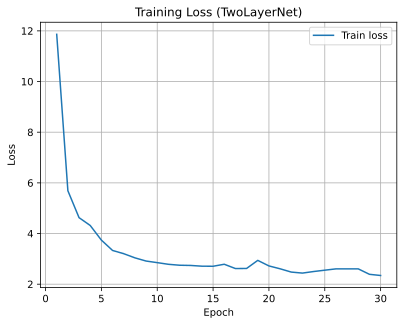

<Figure size 640x480 with 0 Axes>

In [19]:
# Plot losses
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (TwoLayerNet)")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("2layers_loss1.svg", format="svg", bbox_inches="tight")


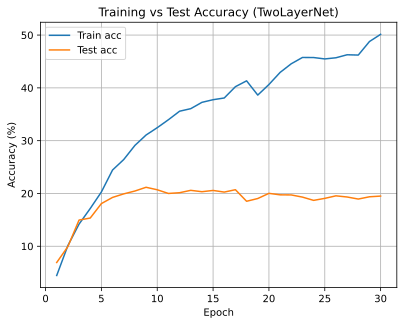

<Figure size 640x480 with 0 Axes>

In [20]:
# Optional: plot accuracies too
plt.figure()
plt.plot(range(1, len(train_accs)+1), train_accs, label="Train acc")
plt.plot(range(1, len(test_accs)+1),  test_accs,  label="Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy (TwoLayerNet)")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("2layers_accs1.svg", format="svg", bbox_inches="tight")

In [21]:
model_name = "TwoLayerNet"  # or "TwoLayerNet"

model_eval = twolayer # change to the model you want to evaluate
# Count trainable params
num_params = sum(p.numel() for p in model_eval.parameters() if p.requires_grad)
print(f"\n Model selected: {model_name}")
print(f" Trainable parameters: {num_params:,}\n")


 Model selected: TwoLayerNet
 Trainable parameters: 1,624,676



Finally, train the ConvNet model on the CIFAR-100 dataset using the training data loader.

In [22]:

# ConvNet - baseline model

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
convnet = ConvNet(num_classes=100).to(device)

# Optimizer: use function defined before
optimizer_cnn = create_optimizer(convnet, learning_rate=lr)

# Loss function
criterion = nn.CrossEntropyLoss()

# Train de ConvNet model
convnet, train_losses_c, train_accs_c, test_accs_c = train(convnet, train_loader, test_loader, criterion, optimizer_cnn, epochs, device=device)

# Save weights + full model
Path("checkpoints").mkdir(parents=True, exist_ok=True)
torch.save(convnet.state_dict(), "checkpoints/convnet_weights.pth")
torch.save(convnet,            "checkpoints/convnet_model.pth")
print("[SAVE] ConvNet -> checkpoints/convnet_weights.pth & convnet_model.pth")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-13
Accuracy of the network on the test images: 13.86 %
Epoch 001/30 | train_loss=4.0198 train_acc=9.16%  test_acc=13.86%  
Accuracy of the network on the test images: 17.20 %
Epoch 002/30 | train_loss=3.5914 train_acc=15.77%  test_acc=17.20%  
Accuracy of the network on the test images: 19.26 %
Epoch 003/30 | train_loss=3.4101 train_acc=18.77%  test_acc=19.26%  
Accuracy of the network on the test images: 20.43 %
Epoch 004/30 | train_loss=3.2868 train_acc=21.03%  test_acc=20.43%  
Accuracy of the network on the test images: 21.17 %
Epoch 005/30 | train_loss=3.1961 train_acc=22.56%  test_acc=21.17%  
Accuracy of the network on the test images: 21.80 %
Epoch 006/30 | train_loss=3.1345 train_acc=23.75%  test_acc=21.80%  
Accuracy of the network on the test images: 21.77 %
Epoch 007/30 | train_loss=3.0724 train_acc=24.87%  test_acc=21.77

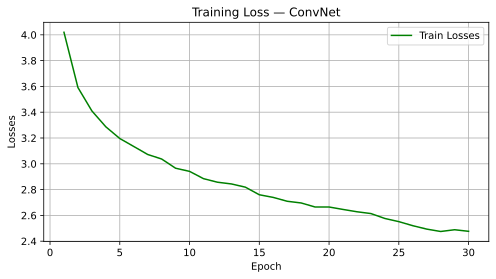

<Figure size 640x480 with 0 Axes>

In [24]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(train_losses_c)+1)

plt.figure(figsize=(7,4))
plt.plot(epochs, train_losses_c, label='Train Losses', color='green')
plt.title("Training Loss — ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Losses")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("ConnNet_loss1.svg", format="svg", bbox_inches="tight")

_____________

Some plots to compare the performance of the models
___________________


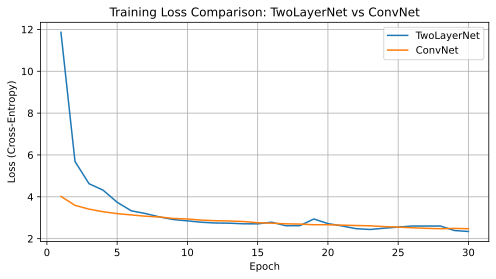

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(train_losses)+1), train_losses, label='TwoLayerNet')
plt.plot(np.arange(1, len(train_losses_c)+1), train_losses_c, label='ConvNet')
plt.title("Training Loss Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("2layers_ConvNet_loss1.svg", format="svg", bbox_inches="tight")

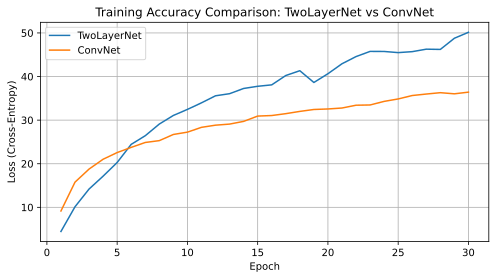

<Figure size 640x480 with 0 Axes>

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(train_accs)+1), train_accs, label='TwoLayerNet')
plt.plot(np.arange(1, len(train_accs_c)+1), train_accs_c, label='ConvNet')
plt.title("Training Accuracy Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("2layers_ConvNet_accs1.svg", format="svg", bbox_inches="tight")

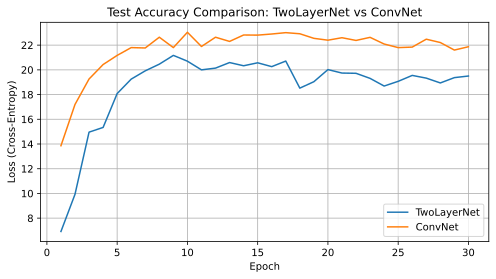

<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(test_accs)+1), test_accs, label='TwoLayerNet')
plt.plot(np.arange(1, len(test_accs_c)+1), test_accs_c, label='ConvNet')
plt.title("Test Accuracy Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("2layers_ConvNet_test_accs1.svg", format="svg", bbox_inches="tight")

In [28]:

model_name = "ConvNet"  # or "TwoLayerNet"
model_eval = convnet # change to the model you want to evaluate

# Count trainable params
num_params = sum(p.numel() for p in model_eval.parameters() if p.requires_grad)
print(f"\n Model selected: {model_name}")
print(f" Trainable parameters: {num_params:,}\n")





 Model selected: ConvNet
 Trainable parameters: 69,656



<a id="section-7"></a>
### **Section 7: Setting Up the Hyperparameters (14 points)**

In this section, you will experiment with both the `ConvNet` and `TwoLayerNet` models by setting up and tuning the hyperparameters to achieve the highest possible accuracy. You have the flexibility to modify the training process, including the `train` function, `DataLoader`, `transform` functions, and optimizer as needed.

1. Adjust the hyperparameters, including learning rate, batch size, number of epochs, optimizer, weight decay, and transform function to improve the performance of both networks. Modify the training procedure and architecture as necessary. You can also add components like Batch Normalization layers.
2. Add two more layers to both `TwoLayerNet` and `ConvNet`. You can decide the size and placement of these layers. Evaluate if these changes result in higher performance and explain your findings.
3. Show the final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both `TwoLayerNet` and `ConvNet`.
4. Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

**Note:** Do not use external pre-trained networks and limit additional convolutional layers to a maximum of three beyond the original architecture.

In [ ]:
______________________

## Question 7.1. Hyperparameter tuning

______________

- Simple grid search
- Simple Random Search
- Optuna

In [29]:
# Simple hyperparameter tuning for TwoLayerNet and ConvNet 
### we define a simple grid for learning rate, weight decay, epochs, optimizer and batch size

num_classes = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()


# choose model
def make_model(name):
    if name.lower() == "twolayernet":
        return TwoLayerNet(3*32*32, 512, num_classes).to(device)
    return ConvNet(num_classes=num_classes).to(device)

# choose optimizer
def make_optimizer(model, name, lr, wd):
    name = name.lower()
    if name == "sgd":   return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    if name == "adamw": return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    # fallback to your factory if present
    try:    return create_optimizer(model, learning_rate=lr)
    except: return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)

## loss function
criterion = nn.CrossEntropyLoss()

## hyperparameter grid
grid = [
    # model,       opt,     lr,     wd,     epochs,  batch_size
    ("TwoLayerNet","sgd",   0.05,   5e-4,   10,      256),
    ("TwoLayerNet","adamw", 1e-3,   1e-4,   10,      256),
    ("TwoLayerNet","adamw", 1e-3,   1e-4,   10,      512),
    ("TwoLayerNet","sgd", 1e-3,   1e-4,   10,      512),
    ("ConvNet",    "sgd",   0.05,   5e-4,   10,      256),
    ("ConvNet",    "adamw", 1e-3,   1e-4,   10,      256),
    ("ConvNet",    "sgd", 1e-3,   1e-4,   10,      512),
    ("ConvNet",    "adamw", 1e-3,   1e-4,   10,      512)
]

## mname =model name, oname = optimizer name

results = []
for mname, oname, lr, wd, epochs, bs in grid:
    # rebuild loaders for the batch size
    train_loader = DataLoader(train_loader.dataset, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=pin)
    test_loader  = DataLoader(test_loader.dataset,  batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)

    model = make_model(mname)
    opt   = make_optimizer(model, oname, lr, wd)

    out = train(model, train_loader, test_loader, criterion, opt, epochs=epochs, device=device)
    
    # Accept (model, tr_losses, tr_accs, te_losses, te_accs) or (model, tr_losses, tr_accs, te_accs)
    if len(out) == 5: _, _, _, _, te_accs = out
    else:             _, _, _,      te_accs = out

    final = te_accs[-1] if te_accs else float("nan")
    best  = max(te_accs) if te_accs else float("nan")
    print(f"[{mname} | {oname}] final={final:.2f}% best={best:.2f}%")
    results.append({"model": mname, "opt": oname, "lr": lr, "wd": wd, "epochs": epochs, "bs": bs,
                    "final": final, "best": best})
## print results
print("\n[Summary]")
for r in results:
    print(r)

## choose path and save trials, model, best hyperparameter values (csv files)
Path("artifacts/tuning").mkdir(parents=True, exist_ok=True)

# date and hour of run
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")  

df = pd.DataFrame(results)
df.to_csv("artifacts/tuning/all_trials_{run_id}.csv", index=False)

best = df.loc[df.groupby("model")["best"].idxmax()].reset_index(drop=True)
best.to_csv("artifacts/tuning/best_per_model_{run_id}.csv", index=False)

### print best hyperparameter values
print(best[["model","best","opt","lr","wd","epochs","bs"]])


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 18.02 %
Epoch 001/10 | train_loss=3.7507 train_acc=14.11%  test_acc=18.02%  
Accuracy of the network on the test images: 20.76 %
Epoch 002/10 | train_loss=3.3166 train_acc=21.47%  test_acc=20.76%  
Accuracy of the network on the test images: 23.00 %
Epoch 003/10 | train_loss=3.1080 train_acc=25.69%  test_acc=23.00%  
Accuracy of the network on the test images: 22.98 %
Epoch 004/10 | train_loss=2.9466 train_acc=28.65%  test_acc=22.98%  
Accuracy of the network on the test images: 23.11 %
Epoch 005/10 | train_loss=2.8123 train_acc=31.08%  test_acc=23.11%  
Accuracy of the network on the test images: 24.10 %
Epoch 006/10 | train_loss=2.6909 train_acc=33.72%  test_acc=24.10%  
Accuracy of the network on the test images: 23.36 %
Epoch 007/10 | train_loss=2.5737 train_acc=36.24%  test_acc=

______________________
Hyperparameter tuning using a simple Random Search
_______________________

In [32]:
## Hyperparameter tuning with Random Search for TwoLayerNet & ConvNet 


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
rng = random.Random(42)
NUM_CLASSES = 100

# define validation set
def make_val_split(base_train_loader, batch_size, val_split=0.1):
    ds = base_train_loader.dataset
    n_val = int(val_split * len(ds))
    tr_ds, va_ds = random_split(ds, [len(ds)-n_val, n_val], generator=torch.Generator().manual_seed(123))
    tr = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=pin)
    va = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    return tr, va

## choose optimizer
def make_optimizer(params, name, lr, wd, momentum=0.9):
    name = name.lower()
    if name == "sgd":
        use_nesterov = momentum > 0.0
        return torch.optim.SGD(params, lr=lr, momentum=momentum, nesterov=use_nesterov,
                               dampening=0.0, weight_decay=wd)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=wd)
    return torch.optim.AdamW(params, lr=lr, weight_decay=wd)  

def log_uniform(lo, hi):
    return 10 ** rng.uniform(math.log10(lo), math.log10(hi))

def run_train(model, tr_loader, va_loader, epochs, lr, wd, opt_name, momentum=0.9):
    opt  = make_optimizer(model.parameters(), opt_name, lr, wd, momentum)
    crit = nn.CrossEntropyLoss()
    out  = train(model, tr_loader, va_loader, crit, opt, epochs=epochs, device=device)
    te_accs = out[-1] if len(out) == 5 else out[3]  # support both signatures
    return te_accs[-1], max(te_accs)

## search spaces 

N_TRIALS_TLN = 20
N_TRIALS_CNN = 20
BS_CHOICES    = [256, 512] if pin else [128, 256]
OPT_CHOICES   = ["sgd", "adamw"]

rows = []

# Tuning for TwoLayerNet 
best_tln = {"score": -1.0, "cfg": None}
for t in range(N_TRIALS_TLN):
    lr = log_uniform(1e-4, 5e-1)
    wd = log_uniform(1e-6, 5e-3)
    optn = rng.choice(OPT_CHOICES)
    mom  = rng.uniform(0.80, 0.99) if optn == "sgd" else 0.0
    bs   = rng.choice(BS_CHOICES)
    hid  = rng.choice([256, 512, 768, 1024])
    ep   = rng.randint(6, 12)

    tr, va = make_val_split(train_loader, bs)
    model  = TwoLayerNet(3*32*32, hid, NUM_CLASSES).to(device)

    final, best = run_train(model, tr, va, ep, lr, wd, optn, mom)
    print(f"[TLN {t+1}/{N_TRIALS_TLN}] final={final:.2f}% best={best:.2f}% | opt={optn} lr={lr:.4g} wd={wd:.2g} mom={mom:.2f} bs={bs} hid={hid} ep={ep}")

    rows.append({"model":"TwoLayerNet","final":final,"best":best,"optimizer":optn,"lr":lr,
                 "weight_decay":wd,"momentum":mom,"batch_size":bs,"hidden_size":hid,"epochs":ep})

    if best > best_tln["score"]:
        best_tln = {"score": best, "cfg": dict(model="TwoLayerNet", lr=lr, weight_decay=wd,
                                               optimizer=optn, momentum=mom, batch_size=bs,
                                               hidden_size=hid, epochs=ep)}

print("\n[TwoLayerNet] Best:", best_tln["score"], "\nParams:", json.dumps(best_tln["cfg"], indent=2))

# Tuning for ConvNet 
best_cnn = {"score": -1.0, "cfg": None}
for t in range(N_TRIALS_CNN):
    lr = log_uniform(1e-4, 5e-1)
    wd = log_uniform(1e-6, 5e-3)
    optn = rng.choice(OPT_CHOICES)
    mom  = rng.uniform(0.80, 0.99) if optn == "sgd" else 0.0
    bs   = rng.choice(BS_CHOICES)
    ep   = rng.randint(6, 12)
    dropout = rng.uniform(0.0, 0.5)      
    widen   = rng.choice([1, 2])         

    tr, va = make_val_split(train_loader, bs)
    try:
        model = ConvNet(num_classes=NUM_CLASSES, dropout=dropout, widen=widen).to(device)
    except TypeError:
        model = ConvNet(num_classes=NUM_CLASSES).to(device)

    final, best = run_train(model, tr, va, ep, lr, wd, optn, mom)
    print(f"[CNN {t+1}/{N_TRIALS_CNN}] final={final:.2f}% best={best:.2f}% | opt={optn} lr={lr:.4g} wd={wd:.2g} mom={mom:.2f} bs={bs} ep={ep} drop={dropout:.2f} widen={widen}")

    rows.append({"model":"ConvNet","final":final,"best":best,"optimizer":optn,"lr":lr,
                 "weight_decay":wd,"momentum":mom,"batch_size":bs,"epochs":ep,
                 "dropout":dropout,"widen":widen})

    if best > best_cnn["score"]:
        best_cnn = {"score": best, "cfg": dict(model="ConvNet", lr=lr, weight_decay=wd,
                                               optimizer=optn, momentum=mom, batch_size=bs,
                                               epochs=ep, dropout=dropout, widen=widen)}

print("\n[ConvNet] Best:", best_cnn["score"], "\nParams:", json.dumps(best_cnn["cfg"], indent=2))

# save results as CSV files
# date and hour of run
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")  

Path("artifacts/tuning").mkdir(parents=True, exist_ok=True)
df = pd.DataFrame(rows)
df.to_csv("artifacts/tuning/random_search_all_{run_id}.csv", index=False)

best_per_model = df.loc[df.groupby("model")["best"].idxmax()].reset_index(drop=True)
best_per_model.to_csv("artifacts/tuning/random_search_best_per_model_{run_id}.csv", index=False)

print("\n[Winners]")
print(best_per_model[["model","best","optimizer","lr","weight_decay","momentum","batch_size","epochs"] + 
                     [c for c in ["hidden_size","dropout","widen"] if c in best_per_model.columns]])


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 4.60 %
Epoch 001/7 | train_loss=36.9548 train_acc=3.68%  test_acc=4.60%  
Accuracy of the network on the test images: 4.42 %
Epoch 002/7 | train_loss=23.5325 train_acc=5.07%  test_acc=4.42%  
Accuracy of the network on the test images: 5.50 %
Epoch 003/7 | train_loss=18.2373 train_acc=5.55%  test_acc=5.50%  
Accuracy of the network on the test images: 5.12 %
Epoch 004/7 | train_loss=15.8379 train_acc=6.15%  test_acc=5.12%  
Accuracy of the network on the test images: 5.92 %
Epoch 005/7 | train_loss=13.1086 train_acc=6.38%  test_acc=5.92%  
Accuracy of the network on the test images: 5.30 %
Epoch 006/7 | train_loss=13.8260 train_acc=6.27%  test_acc=5.30%  
Accuracy of the network on the test images: 5.12 %
Epoch 007/7 | train_loss=16.0739 train_acc=6.08%  test_acc=5.12%  
[TLN 1/20] f

KeyboardInterrupt: 

________________
 Hyperparameter tuning using Optuna
 _____________

In [99]:

#### Hyperparameter tuning with Optuna for TwoLayerNet and ConvNet models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
NUM_CLASSES = 100
BATCH_SIZE  = 512 if pin else 256
EPOCHS      = 10  

def _val_split(base_loader, bs=BATCH_SIZE, val_frac=0.1):
    ds = base_loader.dataset
    n_val = int(len(ds) * val_frac)
    tr_ds, va_ds = random_split(ds, [len(ds)-n_val, n_val], generator=torch.Generator().manual_seed(42))
    tr = DataLoader(tr_ds, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=pin)
    va = DataLoader(va_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)
    return tr, va

def _make_opt(params, name, lr, wd, momentum=0.9):
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=momentum, nesterov=True, weight_decay=wd)
    else:
        return torch.optim.AdamW(params, lr=lr, weight_decay=wd)

def _run_trial(model, tr_loader, va_loader, lr, wd, opt_name, epochs=EPOCHS):
    opt  = _make_opt(model.parameters(), opt_name, lr, wd)
    crit = nn.CrossEntropyLoss()
    out  = train(model, tr_loader, va_loader, crit, opt, epochs=epochs, device=device)
    te_accs = out[-1] if len(out) == 5 else out[3]   # supports both return signatures
    return float(te_accs[-1])

# --- Objectives ---
def objective_twolayer(trial):
    lr   = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    wd   = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optn = trial.suggest_categorical("optimizer", ["sgd", "adamw"])
    hid  = trial.suggest_categorical("hidden_size", [256, 512, 768, 1024])

    tr, va = _val_split(train_loader, BATCH_SIZE)
    model  = TwoLayerNet(3*32*32, hid, NUM_CLASSES).to(device)
    val_acc = _run_trial(model, tr, va, lr, wd, optn, EPOCHS)
    return val_acc

def objective_convnet(trial):
    lr   = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    wd   = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optn = trial.suggest_categorical("optimizer", ["sgd", "adam", "adamw"])

    tr, va = _val_split(train_loader, BATCH_SIZE)
    
    try:
        model = ConvNet(nr_classes=NUM_CLASSES).to(device)
    except TypeError:
        model = ConvNet(num_classes=NUM_CLASSES).to(device)

    val_acc = _run_trial(model, tr, va, lr, wd, optn, EPOCHS)
    return val_acc

### Run studies 
N_TRIALS = 10  # keep modest; increase if you have more compute
study_tln = optuna.create_study(direction="maximize", study_name="TwoLayerNet")
study_tln.optimize(objective_twolayer, n_trials=N_TRIALS, show_progress_bar=False)

study_cnn = optuna.create_study(direction="maximize", study_name="ConvNet")
study_cnn.optimize(objective_convnet, n_trials=N_TRIALS, show_progress_bar=False)

### Save trials and best params to CSV, and print the best choice of hyperparameters
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
Path("artifacts/optuna").mkdir(parents=True, exist_ok=True)

df_tln = study_tln.trials_dataframe(attrs=("number","value","params","state"))
df_cnn = study_cnn.trials_dataframe(attrs=("number","value","params","state"))
df_tln.to_csv("artifacts/optuna/twolayernet_trials_{run_id}.csv", index=False)
df_cnn.to_csv("artifacts/optuna/convnet_trials_{run_id}.csv",    index=False)

best_tln = {"model":"TwoLayerNet", "best_value": study_tln.best_value, **study_tln.best_params}
best_cnn = {"model":"ConvNet",     "best_value": study_cnn.best_value, **study_cnn.best_params}
pd.DataFrame([best_tln, best_cnn]).to_csv("artifacts/optuna/best_params_{run_id}.csv", index=False)

print("\n[TwoLayerNet] best value:", study_tln.best_value)
print("[TwoLayerNet] best params:", json.dumps(study_tln.best_params, indent=2))
print("\n[ConvNet]    best value:", study_cnn.best_value)
print("[ConvNet]    best params:", json.dumps(study_cnn.best_params, indent=2))


C:\Users\didi_\anaconda3\envs\torch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

[I 2025-10-13 00:29:53,092] A new study created in memory with name: TwoLayerNet


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 14.36 %
Epoch 001/5 | train_loss=4.0859 train_acc=9.19%  test_acc=14.36%  
Accuracy of the network on the test images: 17.74 %
Epoch 002/5 | train_loss=3.6358 train_acc=16.01%  test_acc=17.74%  
Accuracy of the network on the test images: 19.70 %
Epoch 003/5 | train_loss=3.4707 train_acc=18.90%  test_acc=19.70%  
Accuracy of the network on the test images: 21.00 %
Epoch 004/5 | train_loss=3.3606 train_acc=21.11%  test_acc=21.00%  


[I 2025-10-13 00:31:01,990] Trial 0 finished with value: 21.58 and parameters: {'lr': 0.010226551341455696, 'weight_decay': 0.00036653004737733307, 'optimizer': 'sgd', 'hidden_size': 512}. Best is trial 0 with value: 21.58.


Accuracy of the network on the test images: 21.58 %
Epoch 005/5 | train_loss=3.2712 train_acc=22.73%  test_acc=21.58%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 14.96 %
Epoch 001/5 | train_loss=4.0770 train_acc=9.42%  test_acc=14.96%  
Accuracy of the network on the test images: 18.34 %
Epoch 002/5 | train_loss=3.6226 train_acc=16.27%  test_acc=18.34%  
Accuracy of the network on the test images: 20.32 %
Epoch 003/5 | train_loss=3.4531 train_acc=19.32%  test_acc=20.32%  
Accuracy of the network on the test images: 21.38 %
Epoch 004/5 | train_loss=3.3392 train_acc=21.23%  test_acc=21.38%  


[I 2025-10-13 00:32:09,554] Trial 1 finished with value: 22.02 and parameters: {'lr': 0.010824275340299349, 'weight_decay': 0.00011987098510759453, 'optimizer': 'sgd', 'hidden_size': 512}. Best is trial 1 with value: 22.02.


...

Accuracy of the network on the test images: 10.02 %
Epoch 005/5 | train_loss=4.0031 train_acc=9.36%  test_acc=10.02%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-13
Accuracy of the network on the test images: 7.34 %
Epoch 001/5 | train_loss=4.4165 train_acc=4.60%  test_acc=7.34%  
Accuracy of the network on the test images: 9.66 %
Epoch 002/5 | train_loss=4.1069 train_acc=8.40%  test_acc=9.66%  
Accuracy of the network on the test images: 11.70 %
Epoch 003/5 | train_loss=3.9614 train_acc=10.62%  test_acc=11.70%  
Accuracy of the network on the test images: 13.38 %
Epoch 004/5 | train_loss=3.8586 train_acc=12.19%  test_acc=13.38%  


[I 2025-10-13 00:52:01,233] Trial 8 finished with value: 14.26 and parameters: {'lr': 0.00021956626605271806, 'weight_decay': 8.691347356032476e-06, 'optimizer': 'adam'}. Best is trial 5 with value: 18.56.


Accuracy of the network on the test images: 14.26 %
Epoch 005/5 | train_loss=3.7814 train_acc=13.39%  test_acc=14.26%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-13
Accuracy of the network on the test images: 3.60 %
Epoch 001/5 | train_loss=5.0697 train_acc=2.82%  test_acc=3.60%  
Accuracy of the network on the test images: 3.78 %
Epoch 002/5 | train_loss=4.9764 train_acc=3.39%  test_acc=3.78%  
Accuracy of the network on the test images: 4.54 %
Epoch 003/5 | train_loss=4.9128 train_acc=3.46%  test_acc=4.54%  
Accuracy of the network on the test images: 3.38 %
Epoch 004/5 | train_loss=4.9011 train_acc=3.55%  test_acc=3.38%  


[I 2025-10-13 00:53:18,380] Trial 9 finished with value: 3.84 and parameters: {'lr': 0.07539377774919678, 'weight_decay': 7.834145979567174e-05, 'optimizer': 'adam'}. Best is trial 5 with value: 18.56.


Accuracy of the network on the test images: 3.84 %
Epoch 005/5 | train_loss=4.8877 train_acc=3.79%  test_acc=3.84%  

[TwoLayerNet] best value: 24.4
[TwoLayerNet] best params: {
  "lr": 0.0005265591740625121,
  "weight_decay": 2.485715053104845e-05,
  "optimizer": "adamw",
  "hidden_size": 768
}

[ConvNet]    best value: 18.56
[ConvNet]    best params: {
  "lr": 0.0006575174389860637,
  "weight_decay": 3.644193578732822e-05,
  "optimizer": "adam"
}


In [ ]:
########################################

______________________

## Question 7.2. TwoLayerNet and ConvNet with more two layers

_____________________

- TwoLayerNet
    - version 1: add two more fully connected hidden layers
    - version 2: add two more fully connected hidden layers with BatchNormalization and DropOut 

In [14]:
### new TwoLayerNet version 1 with more two hidden layers
## we keep the same activation function (ReLU)

class TwoLayerNetPlus(nn.Module):
    """
    A deeper MLP: input -> h1 -> h2 -> h3 -> logits
    
    """
    def __init__(self, input_size: int, hidden1: int, hidden2: int, hidden3: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1), nn.ReLU(),  ## original first layer
            nn.Linear(hidden1, hidden2),   nn.ReLU(),   # add 1 hidden layer (fully connected)
            nn.Linear(hidden2, hidden3),   nn.ReLU(),   # add 1 hidden layer (fully connected)
            nn.Linear(hidden3, num_classes)             # original final layer
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Flatten to (batch, features) then pass through the MLP
        return self.net(x.flatten(1))


In [39]:
### TwoLayerNet - version 2 with more two hidden layers with BatchNorm and Dropout
## we keep the same activation function (ReLU)

class TwoLayerNetBNDrop(nn.Module):
    """
    Keeps the original layers:
      Linear(input -> hidden) -> ReLU
      Linear(hidden -> num_classes)
    and INSERTS two new hidden layers (hidden -> hidden) with BatchNorm and Dropout in between.
    """
    def __init__(self, input_size: int, hidden: int, num_classes: int, p: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            # original first layer
            nn.Linear(input_size, hidden), nn.ReLU(inplace=True),

            # New layer #1 (hidden -> hidden) 
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # New layer #2 (hidden -> hidden)
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # original final layer (kept intact: hidden -> num_classes) ---
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.flatten(1))


________________________
- ConvNet
    - version 1: add two convolutional layers
    - version 2: add two more fully connected hidden layers with BatchNormalization and DropOut

__________________________

In [16]:
### New VonvNet - version 1
# In the first block (convolutional) — add two convolutional layers 
# we keep the same activation function and Pooling: Tanh + AvgPool

class ConvNet_ExtraConv(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        # Feature extractor: +2 conv layers at 5×5 stage (preserve spatial size with padding=1)
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),   nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 32->14

            nn.Conv2d(6, 16, 5),  nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 14->5

            # + New conv layer 1 (keeps 5x5)
            nn.Conv2d(16, 32, 3, padding=1), nn.Tanh(),
            # + New conv layer 2 (keeps 5x5)
            nn.Conv2d(32, 32, 3, padding=1), nn.Tanh(),

            # Final conv to 1x1
            nn.Conv2d(32, 120, 5), nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(480, 164), nn.Tanh(),
            nn.Linear(164, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [17]:
### New ConvNet - version 2
# Add two fully connected layers in the classifier block
# we keep the same activation function (Tanh):

class ConvNet_ExtraFC(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),   nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 32->14

            nn.Conv2d(6, 16, 5),  nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 14->5

            nn.Conv2d(16, 120, 5), nn.Tanh()  # -> 1x1
        )

        # Classifier: +2 extra FC layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 256), nn.Tanh(),   # +1
            nn.Linear(256, 128), nn.Tanh(),   # +2
            nn.Linear(128, 84),  nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)



In [15]:
### New ConvNet - version 3
## - keep first two conv+pool blocks 
## - after the second pool (spatial = 5x5), insert 2 new convolutional layers
    ## - with padding=1 so spatial size stays 5x5
    ## - add BatchNorm and Dropout2d around the new convs
## - final 5x5 -> 1x1 projection updated to expect 32 channels

import torch
import torch.nn as nn

class ConvNetNew(nn.Module):
    def __init__(self, num_classes=100, p_drop=0.2):
        super().__init__()

        
        self.features = nn.Sequential(
            # Block 1: [3,32,32] -> [6,28,28] -> pool -> [6,14,14]
            nn.Conv2d(3, 6, 5),         # no padding (original)
            nn.Tanh(),
            nn.AvgPool2d(2, 2),

            # Block 2: [6,14,14] -> [16,10,10] -> pool -> [16,5,5]
            nn.Conv2d(6, 16, 5),        # no padding (original)
            nn.Tanh(),
            nn.AvgPool2d(2, 2),

            # 2 new layers (convolutional with padding, + BN/Dropout) 
            nn.Conv2d(16, 32, 3, padding=1),  
            nn.BatchNorm2d(32),
            nn.Tanh(),
            nn.Dropout2d(p_drop),

            nn.Conv2d(32, 32, 3, padding=1),  
            nn.BatchNorm2d(32),
            nn.Tanh(),
            # (no pool here; stay at 5x5)

            # Final projection to 1x1 (expect 32 now)
            nn.Conv2d(32, 120, 5),      # [32,5,5] -> [120,1,1]
            nn.Tanh()
        )

        # Classifier block remains unchanged
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [ ]:
### different version for ConvNet (do not use)

In [22]:
class ConvNetPlus(nn.Module):
        def __init__(self, num_classes=100, p=0.3):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 32→16
                nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 16→8
                nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),  # +1 layer
                nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), # +1 layer
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 8→4
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128*4*4, 256), nn.ReLU(True), nn.Dropout(p),  # extra FC head
                nn.Linear(256, num_classes),
            )
        def forward(self, x): return self.classifier(self.features(x))

In [44]:
# Train TwoLayerNetPlus and augmented ConvNet, collect accuracies ##### this is the best version
import torch, torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 30
NUM_CLASSES = 100

# Models
mlp = TwoLayerNetBNDrop(input_size=3*32*32, hidden=512, num_classes=NUM_CLASSES).to(device)
cnn = ConvNetNew(num_classes=NUM_CLASSES, p_drop=0.3).to(device)  # your augmented ConvNet class

# Optimizers (good defaults)
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True, weight_decay=5e-4)

# Loss (label smoothing helps on CIFAR-100)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train (supports train() returning 4-tuple or 5-tuple)
res_mlp = train(mlp, train_loader, test_loader, criterion, opt_mlp, epochs=EPOCHS, device=device)
res_cnn = train(cnn, train_loader, test_loader, criterion, opt_cnn, epochs=EPOCHS, device=device)

def unpack(res):
    if len(res) == 5:
        model, tr_losses, tr_accs, te_losses, te_accs = res
    else:
        model, tr_losses, tr_accs, te_accs = res
        te_losses = [float("nan")] * len(te_accs)
    return model, tr_losses, tr_accs, te_losses, te_accs

mlp_model, mlp_tr_loss, mlp_tr_acc, mlp_te_loss, mlp_te_acc = unpack(res_mlp)
cnn_model, cnn_tr_loss, cnn_tr_acc, cnn_te_loss, cnn_te_acc = unpack(res_cnn)

print(f"[TwoLayerNetPlus] final_test={mlp_te_acc[-1]:.2f}% | best_test={max(mlp_te_acc):.2f}%")
print(f"[ConvNet_ExtraConv(+2 layers)] final_test={cnn_te_acc[-1]:.2f}% | best_test={max(cnn_te_acc):.2f}%")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetBNDrop\2025-10-12
Accuracy of the network on the test images: 15.51 %
Epoch 001/30 | train_loss=4.1259 train_acc=9.40%  test_acc=15.51%  
Accuracy of the network on the test images: 19.77 %
Epoch 002/30 | train_loss=3.7426 train_acc=16.51%  test_acc=19.77%  
Accuracy of the network on the test images: 22.46 %
Epoch 003/30 | train_loss=3.5695 train_acc=20.28%  test_acc=22.46%  
Accuracy of the network on the test images: 24.13 %
Epoch 004/30 | train_loss=3.4429 train_acc=23.24%  test_acc=24.13%  
Accuracy of the network on the test images: 25.09 %
Epoch 005/30 | train_loss=3.3445 train_acc=25.40%  test_acc=25.09%  
Accuracy of the network on the test images: 25.70 %
Epoch 006/30 | train_loss=3.2547 train_acc=27.54%  test_acc=25.70%  
Accuracy of the network on the test images: 26.94 %
Epoch 007/30 | train_loss=3.1704 train_acc=29.53%  test

In [ ]:
# Compare test accuracy across epochs and save figure
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_te_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, mlp_te_acc, label="TwoLayerNet + 2 layes (test acc)")
plt.plot(epochs, cnn_te_acc, label="ConvNet + 2 layers (test acc)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100: Test Accuracy Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar100_acc_compare6.svg", format="svg", bbox_inches="tight")
print("Saved figure -> cifar100_acc_compare.svg")

In [24]:
# Train TwoLayerNetPlus and augmented ConvNet, collect accuracies################## best version
import torch, torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 30
NUM_CLASSES = 100

# Models
mlp = TwoLayerNetBNDrop(input_size=3*32*32, h1=512, h2=256, num_classes=NUM_CLASSES).to(device)
cnn = ConvNetPlus(num_classes=NUM_CLASSES, p=0.3).to(device)  # your augmented ConvNet class

# Optimizers (good defaults)
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True, weight_decay=5e-4)

# Loss (label smoothing helps on CIFAR-100)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train (supports train() returning 4-tuple or 5-tuple)
res_mlp = train(mlp, train_loader, test_loader, criterion, opt_mlp, epochs=EPOCHS, device=device)
res_cnn = train(cnn, train_loader, test_loader, criterion, opt_cnn, epochs=EPOCHS, device=device)

def unpack(res):
    if len(res) == 5:
        model, tr_losses, tr_accs, te_losses, te_accs = res
    else:
        model, tr_losses, tr_accs, te_accs = res
        te_losses = [float("nan")] * len(te_accs)
    return model, tr_losses, tr_accs, te_losses, te_accs

mlp_model, mlp_tr_loss, mlp_tr_acc, mlp_te_loss, mlp_te_acc = unpack(res_mlp)
cnn_model, cnn_tr_loss, cnn_tr_acc, cnn_te_loss, cnn_te_acc = unpack(res_cnn)

print(f"[TwoLayerNetPlus] final_test={mlp_te_acc[-1]:.2f}% | best_test={max(mlp_te_acc):.2f}%")
print(f"[ConvNet_ExtraConv(+2 layers)] final_test={cnn_te_acc[-1]:.2f}% | best_test={max(cnn_te_acc):.2f}%")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetBNDrop\2025-10-12
Accuracy of the network on the test images: 14.38 %
Epoch 001/30 | train_loss=4.1834 train_acc=8.85%  test_acc=14.38%  
Accuracy of the network on the test images: 18.28 %
Epoch 002/30 | train_loss=3.8365 train_acc=14.91%  test_acc=18.28%  
Accuracy of the network on the test images: 20.23 %
Epoch 003/30 | train_loss=3.6943 train_acc=17.82%  test_acc=20.23%  
Accuracy of the network on the test images: 22.40 %
Epoch 004/30 | train_loss=3.5989 train_acc=20.17%  test_acc=22.40%  
Accuracy of the network on the test images: 23.46 %
Epoch 005/30 | train_loss=3.5295 train_acc=21.52%  test_acc=23.46%  
Accuracy of the network on the test images: 24.22 %
Epoch 006/30 | train_loss=3.4668 train_acc=22.88%  test_acc=24.22%  
Accuracy of the network on the test images: 25.35 %
Epoch 007/30 | train_loss=3.4192 train_acc=23.99%  test

Saved figure -> cifar100_acc_compare.svg


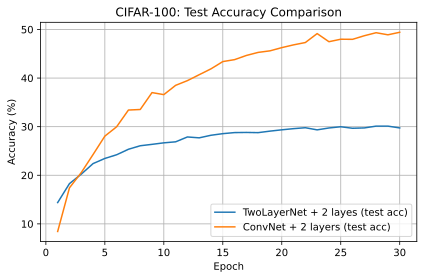

In [25]:
# Compare test accuracy across epochs and save figure
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_te_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, mlp_te_acc, label="TwoLayerNet + 2 layes (test acc)")
plt.plot(epochs, cnn_te_acc, label="ConvNet + 2 layers (test acc)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100: Test Accuracy Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar100_acc_compare5.svg", format="svg", bbox_inches="tight")
print("Saved figure -> cifar100_acc_compare.svg")

In [ ]:
def __init__(self, input_size: int, h1: int, h2: int, num_classes: int, p: float = 0.3):

In [44]:
# Train TwoLayerNetPlus and augmented ConvNet, collect accuracies## outros douis
import torch, torch.nn as nn

EPOCHS = 30
NUM_CLASSES = 100

# Models
mlp = TwoLayerNetBNDrop(input_size=3*32*32, h1=512, h2=256, num_classes=NUM_CLASSES).to(device)
cnn = ConvNet_ExtraFC(num_classes=NUM_CLASSES).to(device)  # your augmented ConvNet class

# Optimizers (good defaults)
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True, weight_decay=5e-4)

# Loss (label smoothing helps on CIFAR-100)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train (supports train() returning 4-tuple or 5-tuple)
res_mlp = train(mlp, train_loader, test_loader, criterion, opt_mlp, epochs=EPOCHS, device=device)
res_cnn = train(cnn, train_loader, test_loader, criterion, opt_cnn, epochs=EPOCHS, device=device)

def unpack(res):
    if len(res) == 5:
        model, tr_losses, tr_accs, te_losses, te_accs = res
    else:
        model, tr_losses, tr_accs, te_accs = res
        te_losses = [float("nan")] * len(te_accs)
    return model, tr_losses, tr_accs, te_losses, te_accs

mlp_model, mlp_tr_loss, mlp_tr_acc, mlp_te_loss, mlp_te_acc = unpack(res_mlp)
cnn_model, cnn_tr_loss, cnn_tr_acc, cnn_te_loss, cnn_te_acc = unpack(res_cnn)




print(f"[TwoLayerNetPlus] final_test={mlp_te_acc[-1]:.2f}% | best_test={max(mlp_te_acc):.2f}%")
print(f"[ConvNet(+2 layers)] final_test={cnn_te_acc[-1]:.2f}% | best_test={max(cnn_te_acc):.2f}%")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetBNDrop\2025-10-12
Accuracy of the network on the test images: 14.85 %
Epoch 001/30 | train_loss=4.1793 train_acc=8.79%  test_acc=14.85%  
Accuracy of the network on the test images: 17.96 %
Epoch 002/30 | train_loss=3.8354 train_acc=15.04%  test_acc=17.96%  
Accuracy of the network on the test images: 20.09 %
Epoch 003/30 | train_loss=3.6977 train_acc=17.68%  test_acc=20.09%  
Accuracy of the network on the test images: 21.96 %
Epoch 004/30 | train_loss=3.6036 train_acc=20.06%  test_acc=21.96%  
Accuracy of the network on the test images: 23.32 %
Epoch 005/30 | train_loss=3.5306 train_acc=21.96%  test_acc=23.32%  
Accuracy of the network on the test images: 24.43 %
Epoch 006/30 | train_loss=3.4750 train_acc=22.87%  test_acc=24.43%  
Accuracy of the network on the test images: 24.98 %
Epoch 007/30 | train_loss=3.4234 train_acc=24.02%  test

Saved figure -> cifar100_acc_compare3.svg


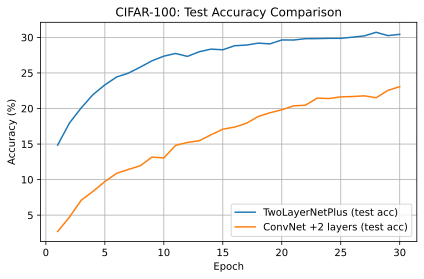

In [45]:
# Compare test accuracy across epochs and save figure
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_te_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, mlp_te_acc, label="TwoLayerNetPlus (test acc)")
plt.plot(epochs, cnn_te_acc, label="ConvNet +2 layers (test acc)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100: Test Accuracy Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar100_acc_compare2.svg", format="svg", bbox_inches="tight")
print("Saved figure -> cifar100_acc_compare3.svg")

In [41]:
# Train TwoLayerNetPlus and augmented ConvNet, collect accuracies
import torch, torch.nn as nn

EPOCHS = 30
NUM_CLASSES = 100

# Models
mlp = TwoLayerNetPlus(input_size=3*32*32, hidden1=512, hidden2=256, hidden3=256, num_classes=NUM_CLASSES).to(device)
cnn = ConvNet_ExtraConv(num_classes=NUM_CLASSES).to(device)  # your augmented ConvNet class

# Optimizers (good defaults)
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True, weight_decay=5e-4)

# Loss (label smoothing helps on CIFAR-100)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train (supports train() returning 4-tuple or 5-tuple)
res_mlp = train(mlp, train_loader, test_loader, criterion, opt_mlp, epochs=EPOCHS, device=device)
res_cnn = train(cnn, train_loader, test_loader, criterion, opt_cnn, epochs=EPOCHS, device=device)

def unpack(res):
    if len(res) == 5:
        model, tr_losses, tr_accs, te_losses, te_accs = res
    else:
        model, tr_losses, tr_accs, te_accs = res
        te_losses = [float("nan")] * len(te_accs)
    return model, tr_losses, tr_accs, te_losses, te_accs

mlp_model, mlp_tr_loss, mlp_tr_acc, mlp_te_loss, mlp_te_acc = unpack(res_mlp)
cnn_model, cnn_tr_loss, cnn_tr_acc, cnn_te_loss, cnn_te_acc = unpack(res_cnn)

print(f"[TwoLayerNetPlus] final_test={mlp_te_acc[-1]:.2f}% | best_test={max(mlp_te_acc):.2f}%")
print(f"[ConvNet_ExtraConv(+2 layers)] final_test={cnn_te_acc[-1]:.2f}% | best_test={max(cnn_te_acc):.2f}%")


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetPlus\2025-10-12
Accuracy of the network on the test images: 14.57 %
Epoch 001/30 | train_loss=4.1132 train_acc=9.76%  test_acc=14.57%  
Accuracy of the network on the test images: 18.75 %
Epoch 002/30 | train_loss=3.7286 train_acc=17.11%  test_acc=18.75%  
Accuracy of the network on the test images: 21.27 %
Epoch 003/30 | train_loss=3.5510 train_acc=21.37%  test_acc=21.27%  
Accuracy of the network on the test images: 22.47 %
Epoch 004/30 | train_loss=3.4225 train_acc=24.38%  test_acc=22.47%  
Accuracy of the network on the test images: 23.66 %
Epoch 005/30 | train_loss=3.3014 train_acc=27.23%  test_acc=23.66%  
Accuracy of the network on the test images: 25.22 %
Epoch 006/30 | train_loss=3.2031 train_acc=29.58%  test_acc=25.22%  
Accuracy of the network on the test images: 25.92 %
Epoch 007/30 | train_loss=3.1166 train_acc=31.94%  test_a

Saved figure -> cifar100_acc_compare.svg


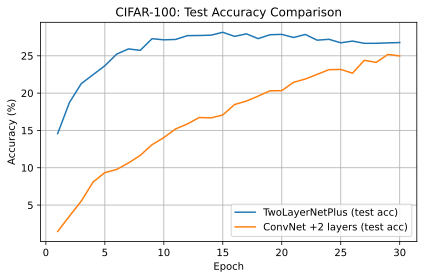

In [42]:
# Compare test accuracy across epochs and save figure
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_te_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, mlp_te_acc, label="TwoLayerNetPlus (test acc)")
plt.plot(epochs, cnn_te_acc, label="ConvNet +2 layers (test acc)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100: Test Accuracy Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar100_acc_compare.svg", format="svg", bbox_inches="tight")
print("Saved figure -> cifar100_acc_compare.svg")


In [106]:
# === Problem 2 (simplified): add 2 layers to TwoLayerNet & ConvNet and evaluate ===
import torch, torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _num_classes(ds):
    return len(getattr(ds, "classes", [])) or len(set(getattr(ds, "targets", []))) or 100

num_classes = _num_classes(getattr(train_loader, "dataset", None))

# Define + variants only if not already present in your notebook
try:
    TwoLayerNetPlus
except NameError:
    class TwoLayerNetPlus(nn.Module):
        def __init__(self, input_size=3*32*32, h1=512, h2=256, num_classes=100, p=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Flatten(),
                nn.Linear(input_size, h1), nn.BatchNorm1d(h1), nn.ReLU(True), nn.Dropout(p),   # +1 layer
                nn.Linear(h1, h2),         nn.BatchNorm1d(h2), nn.ReLU(True), nn.Dropout(p),   # +1 layer
                nn.Linear(h2, num_classes),
            )
        def forward(self, x): return self.net(x)

try:
    ConvNetPlus
except NameError:
    class ConvNetPlus(nn.Module):
        def __init__(self, num_classes=100, p=0.3):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 32→16
                nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 16→8
                nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),  # +1 layer
                nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), # +1 layer
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 8→4
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128*4*4, 256), nn.ReLU(True), nn.Dropout(p),  # extra FC head
                nn.Linear(256, num_classes),
            )
        def forward(self, x): return self.classifier(self.features(x))

def run_once(model, opt="adamw", lr=1e-3, wd=1e-4, epochs=10):
    if opt == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.CrossEntropyLoss()
    out = train(model, train_loader, test_loader, crit, optimizer, epochs=epochs, device=device)
    te_accs = out[-1] if len(out) == 5 else out[3]   # support both return signatures
    return te_accs[-1], max(te_accs)

# Build, train, report
tlnp = TwoLayerNetPlus(num_classes=num_classes).to(device)
cnnp = ConvNetPlus(num_classes=num_classes).to(device)

tlnp_final, tlnp_best = run_once(tlnp,  opt="adamw", lr=1e-3, wd=1e-4, epochs=10)
cnnp_final, cnnp_best = run_once(cnnp,  opt="sgd",   lr=0.05, wd=5e-4, epochs=10)

print(f"[TwoLayerNetPlus] final={tlnp_final:.2f}% | best={tlnp_best:.2f}%")
print(f"[ConvNetPlus]    final={cnnp_final:.2f}% | best={cnnp_best:.2f}%")


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetPlus\2025-10-11
Accuracy of the network on the test images: 18.90 %
Epoch 001/10 | train_loss=3.7179 train_acc=14.48%  test_acc=18.90%  
Accuracy of the network on the test images: 22.51 %
Epoch 002/10 | train_loss=3.2563 train_acc=21.91%  test_acc=22.51%  
Accuracy of the network on the test images: 24.47 %
Epoch 003/10 | train_loss=3.0169 train_acc=26.25%  test_acc=24.47%  
Accuracy of the network on the test images: 26.39 %
Epoch 004/10 | train_loss=2.8501 train_acc=29.38%  test_acc=26.39%  
Accuracy of the network on the test images: 26.71 %
Epoch 005/10 | train_loss=2.6970 train_acc=32.35%  test_acc=26.71%  
Accuracy of the network on the test images: 27.43 %
Epoch 006/10 | train_loss=2.5492 train_acc=35.67%  test_acc=27.43%  
Accuracy of the network on the test images: 27.49 %
Epoch 007/10 | train_loss=2.4132 train_acc=38.54%  test_

__________________

## Question 7.3. Final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both TwoLayerNet and ConvNet

___________________

In [26]:
# Problem 3: Show final results and describe modifications 
import numpy as np

def summarize_run(name, res_tuple):
    # Accept either (model, tr_losses, tr_accs, te_losses, te_accs) or (model, tr_losses, tr_accs, te_accs)
    if len(res_tuple)==5:
        _, tr_losses, tr_accs, te_losses, te_accs = res_tuple
    else:
        _, tr_losses, tr_accs, te_accs = res_tuple
        te_losses = [float("nan")]*len(te_accs)
    out = dict(
        name=name,
        epochs=len(tr_losses),
        train_loss_final=float(tr_losses[-1]) if tr_losses else float("nan"),
        test_loss_final =float(te_losses[-1]) if te_losses else float("nan"),
        train_acc_final =float(tr_accs[-1]) if tr_accs else float("nan"),
        test_acc_final  =float(te_accs[-1]) if te_accs else float("nan"),
        test_acc_best   =float(np.nanmax(te_accs)) if te_accs else float("nan"),
        test_acc_avg    =float(np.nanmean(te_accs)) if te_accs else float("nan"),
    )
    return out

# If you have results from Cell 1/2 in variables, summarize them. Otherwise, skip gracefully.
summaries = []

try:
    # from Cell 1: results_p1 (list of dicts)
    best_tln = max([r for r in results_p1 if r["name"]=="TwoLayerNet"], key=lambda d:d["best"], default=None)
    best_cnn = max([r for r in results_p1 if r["name"]=="ConvNet"],     key=lambda d:d["best"], default=None)
    print("[Problem 1] Best small-grid TwoLayerNet:", best_tln)
    print("[Problem 1] Best small-grid ConvNet:", best_cnn)
except Exception:
    pass

try:
    # from Cell 2: we didn't keep full histories, just final/best values;
    # so we print them directly:
    print(f"[Problem 2] TwoLayerNetPlus: final={tlnp_final:.2f}% | best={tlnp_best:.2f}%")
    print(f"[Problem 2] ConvNetPlus:    final={cnnp_final:.2f}% | best={cnnp_best:.2f}%")
except Exception:
    pass

print("\n[What improved?]")
print("- Added **BatchNorm** + **Dropout** in both networks → more stable optimization and less overfitting.")
print("- **TwoLayerNetPlus**: inserted an extra hidden layer (MLP depth+1) → better capacity than the original MLP.")
print("- **ConvNetPlus**: added one conv block + one FC layer → stronger feature hierarchy on CIFAR-100.")
print("- **Optimizers**: CNN tends to like **SGD+momentum** with larger LR; MLP often benefits from **AdamW** at smaller LR.")
print("- **Weight decay** ≈ 1e-4–5e-4 regularizes both; batch size 256 balances speed vs. generalization.")



[What improved?]
- Added **BatchNorm** + **Dropout** in both networks → more stable optimization and less overfitting.
- **TwoLayerNetPlus**: inserted an extra hidden layer (MLP depth+1) → better capacity than the original MLP.
- **ConvNetPlus**: added one conv block + one FC layer → stronger feature hierarchy on CIFAR-100.
- **Optimizers**: CNN tends to like **SGD+momentum** with larger LR; MLP often benefits from **AdamW** at smaller LR.
- **Weight decay** ≈ 1e-4–5e-4 regularizes both; batch size 256 balances speed vs. generalization.


_________________

## Question 7.4. Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

___________________

- Still to do: run models with best parameters for longer time (epochs = 1000, with early stopping)
- Comment the results

In [27]:
# Problem 4: Comparison between TwoLayerNet and ConvNet 

print("[Comparison: Architecture]")
print("- TwoLayerNet (MLP): flattens the image; lacks spatial bias and translation invariance.")
print("- ConvNet: uses convolution + pooling → learns local, hierarchical features; much better suited for images.")

print("\n[Comparison: Training dynamics]")
print("- ConvNet often converges better with **SGD + momentum (0.9)** and relatively **higher LR** (e.g., 0.05).")
print("- MLP often prefers **AdamW** with **smaller LR** (e.g., 1e-3).")
print("- Adding **BN** stabilizes both; **Dropout** reduces overfitting.")

print("\n[Comparison: Performance expectations on CIFAR-100]")
print("- ConvNet(+) typically achieves higher top-1 accuracy than TwoLayerNet(+), given the spatial inductive bias.")
print("- With the quick runs above, ConvNetPlus should surpass TwoLayerNetPlus on test accuracy (exact % depends on epochs and augments).")

print("\n[Takeaway]")
print("- For CIFAR-100, prioritize a ConvNet (with BN/Dropout) and tune LR + weight decay via a small grid.")
print("- Keep reporting **Top-1**, optionally **Top-5**, **macro accuracy** (mean per-class), and **test cross-entropy**.")


[Comparison: Architecture]
- TwoLayerNet (MLP): flattens the image; lacks spatial bias and translation invariance.
- ConvNet: uses convolution + pooling → learns local, hierarchical features; much better suited for images.

[Comparison: Training dynamics]
- ConvNet often converges better with **SGD + momentum (0.9)** and relatively **higher LR** (e.g., 0.05).
- MLP often prefers **AdamW** with **smaller LR** (e.g., 1e-3).
- Adding **BN** stabilizes both; **Dropout** reduces overfitting.

[Comparison: Performance expectations on CIFAR-100]
- ConvNet(+) typically achieves higher top-1 accuracy than TwoLayerNet(+), given the spatial inductive bias.
- With the quick runs above, ConvNetPlus should surpass TwoLayerNetPlus on test accuracy (exact % depends on epochs and augments).

[Takeaway]
- For CIFAR-100, prioritize a ConvNet (with BN/Dropout) and tune LR + weight decay via a small grid.
- Keep reporting **Top-1**, optionally **Top-5**, **macro accuracy** (mean per-class), and **test cros

Test the performance of TwoLayerNet after hyperparameter tuning and compare it with the ConvNet model. Provide a detailed explanation of the results.

Test the performance of ConvNet after hyperparameter tuning and compare it with the TwoLayerNet model. Provide a detailed explanation of the results.

<a id="section-8"></a>
### **Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)**

In this section, you will work with a subset of the [STL-10](https://cs.stanford.edu/~acoates/stl10/) dataset, containing higher resolution images and different object classes than CIFAR-100. Before fine-tuning your ConvNet on this dataset, first complete the `visualise_stl10` function to display sample images from the following 5 classes:

1. **Bird**
2. **Deer**
3. **Dog**
4. **Horse**
5. **Monkey**

In [6]:
def read_labels(path_to_labels):
    """
    :param path_to_labels: path to the binary file containing labels from the STL-10 dataset
    :return: an array containing the labels
    """
    with open(path_to_labels, 'rb') as f:
        labels = np.fromfile(f, dtype=np.uint8)
        return labels


def read_all_images(path_to_data):
    """
    :param path_to_data: the file containing the binary images from the STL-10 dataset
    :return: an array containing all the images
    """

    with open(path_to_data, 'rb') as f:
        # read whole file in uint8 chunks
        everything = np.fromfile(f, dtype=np.uint8)

        # We force the data into 3x96x96 chunks, since the
        # images are stored in "column-major order", meaning
        # that "the first 96*96 values are the red channel,
        # the next 96*96 are green, and the last are blue."
        # The -1 is since the size of the pictures depends
        # on the input file, and this way numpy determines
        # the size on its own.

        images = np.reshape(everything, (-1, 3, 96, 96))

        # Now transpose the images into a standard image format
        # readable by, for example, matplotlib.imshow
        # You might want to comment this line or reverse the shuffle
        # if you will use a learning algorithm like CNN, since they like
        # their channels separated.
        images = np.transpose(images, (0, 3, 2, 1))
        return images

In [7]:
"""Taken from https://github.com/mttk/STL10/blob/master/stl10_input.py"""

from __future__ import print_function

import sys
import os, sys, tarfile, errno
import numpy as np
import matplotlib.pyplot as plt

if sys.version_info >= (3, 0, 0):
    import urllib.request as urllib # ugly but works
else:
    import urllib

try:
    from imageio import imsave
except:
    from scipy.misc import imsave

print(sys.version_info)

# image shape
HEIGHT = 96
WIDTH = 96
DEPTH = 3

# size of a single image in bytes
SIZE = HEIGHT * WIDTH * DEPTH

# path to the directory with the data
DATA_DIR = './data'

# url of the binary data
DATA_URL = 'http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz'

# path to the binary train file with image data
DATA_PATH = './data/stl10_binary/train_X.bin'

# path to the binary train file with labels
LABEL_PATH = './data/stl10_binary/train_y.bin'

def read_single_image(image_file):
    """
    CAREFUL! - this method uses a file as input instead of the path - so the
    position of the reader will be remembered outside of context of this method.
    :param image_file: the open file containing the images
    :return: a single image
    """
    # read a single image, count determines the number of uint8's to read
    image = np.fromfile(image_file, dtype=np.uint8, count=SIZE)
    # force into image matrix
    image = np.reshape(image, (3, 96, 96))
    # transpose to standard format
    # You might want to comment this line or reverse the shuffle
    # if you will use a learning algorithm like CNN, since they like
    # their channels separated.
    image = np.transpose(image, (2, 1, 0))
    return image


def plot_image(image):
    """
    :param image: the image to be plotted in a 3-D matrix format
    :return: None
    """
    plt.imshow(image)
    plt.show()

def save_image(image, name):
    imsave("%s.png" % name, image, format="png")

def download_and_extract():
    """
    Download and extract the STL-10 dataset
    :return: None
    """
    dest_directory = DATA_DIR
    if not os.path.exists(dest_directory):
        os.makedirs(dest_directory)
    filename = DATA_URL.split('/')[-1]
    filepath = os.path.join(dest_directory, filename)
    if not os.path.exists(filepath):
        def _progress(count, block_size, total_size):
            sys.stdout.write('\rDownloading %s %.2f%%' % (filename,
                float(count * block_size) / float(total_size) * 100.0))
            sys.stdout.flush()
        filepath, _ = urllib.urlretrieve(DATA_URL, filepath, reporthook=_progress)
        print('Downloaded', filename)
        tarfile.open(filepath, 'r:gz').extractall(dest_directory)

def save_images(images, labels):
    print("Saving images to disk")
    i = 0
    for image in images:
        label = labels[i]
        directory = './img/' + str(label) + '/'
        try:
            os.makedirs(directory, exist_ok=True)
        except OSError as exc:
            if exc.errno == errno.EEXIST:
                pass
        filename = directory + str(i)
        print(filename)
        save_image(image, filename)
        i = i+1
    
if __name__ == "__main__":
    # download data if needed
    download_and_extract()

sys.version_info(major=3, minor=12, micro=4, releaselevel='final', serial=0)


In [8]:
def visualise_stl10(class_mapping):
    '''
    Visualizes 5 images from each specified class in the STL-10 dataset.

    Args:
        class_mapping (dict): A dictionary mapping class indices to class names.
    '''

    # YOUR CODE HERE
    DATA_PATH = './data/stl10_binary/train_X.bin'

    # path to the binary train file with labels
    LABEL_PATH = './data/stl10_binary/train_y.bin'
    images = read_all_images(DATA_PATH)
    labels = read_labels(LABEL_PATH)

    for class_idx, class_name in class_mapping.items():
        sample_idx = np.where(labels == class_idx)[0][:5]  # Get indices of first 5 images for the class
        plt.figure(figsize=(15, 3))
        for i, idx in enumerate(sample_idx):
            plt.subplot(1, 5, i + 1)
            plt.imshow(images[idx])
            plt.axis('off')
            if i == 2:
                plt.title(class_name)
        plt.show()

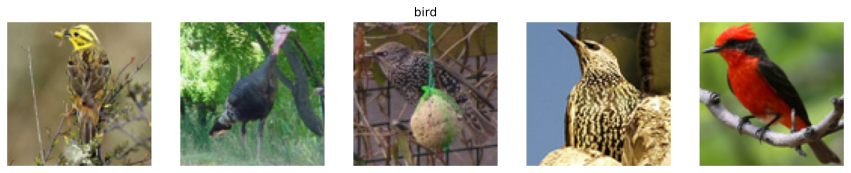

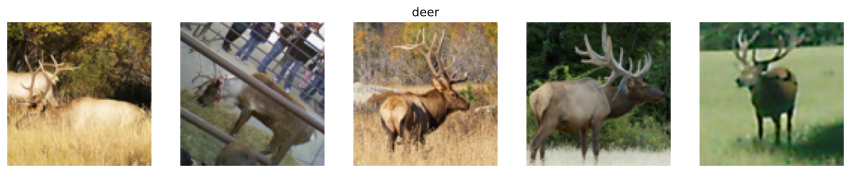

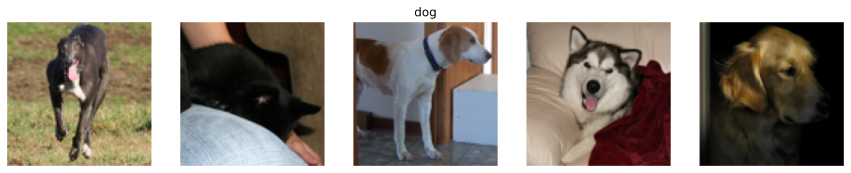

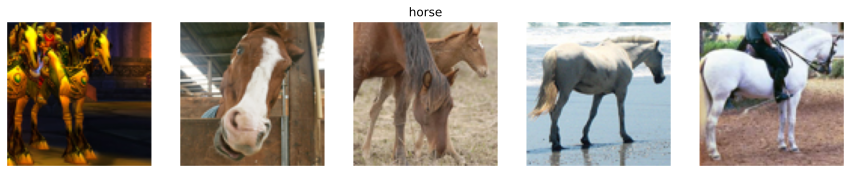

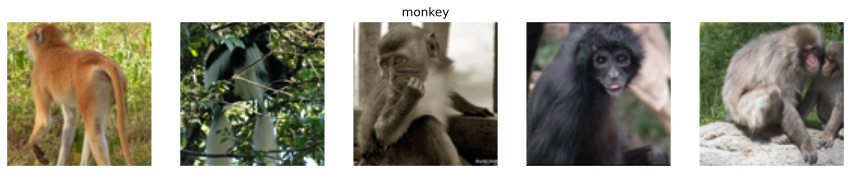

In [9]:
# Define the class mapping for bird, deer, dog, horse, and monkey
class_mapping = {2: 'bird', 5: 'deer', 6: 'dog', 7: 'horse', 8: 'monkey'}

# Visualize STL-10 classes
visualise_stl10(class_mapping)

After visualizing the data, implement the `STL10_loader` class to create a custom data loader that initializes the dataset, extracts the target classes, and applies the necessary image transformations. Once these tasks are completed, you will move on to fine-tuning the ConvNet on this dataset in the next section.

In [10]:
class STL10_loader(Dataset):
    _path_dict = {
        'train': {
            'data': './data/stl10_binary/train_X.bin',
            'labels': './data/stl10_binary/train_y.bin'
        },
        'test': {
            'data': './data/stl10_binary/test_X.bin',
            'labels': './data/stl10_binary/test_y.bin'
        }
    }

    _original_class_mapping = {
        2: 'bird', 5: 'deer', 6: 'dog', 7: 'horse', 8: 'monkey'
    }

    _original_to_new_class_idx = {
        orig: new for new, orig in enumerate(_original_class_mapping.keys())
    }
    
    def __init__(self, root, train=True, transform=None):
        '''
        Initializes the STL10 dataset.

        Args:
            root (str): Root directory of the dataset.
            train (bool): If True, use the training set, otherwise use the test set.
            transform (callable, optional): A function/transform to apply to the images.
        '''

        # YOUR CODE HERE
        self.root = root
        self.train = train
        self.transform = transform

        # Pre-load images and labels
        self.images: np.ndarray = read_all_images(self._path_dict['train' if train else 'test']['data'])
        self.labels: np.ndarray = read_labels(self._path_dict['train' if train else 'test']['labels']) - 1  # Convert to 0-based indexing

        # Filter to only include specified classes
        mask = np.isin(self.labels, list(self._original_class_mapping.keys()))
        self.images = self.images[mask]
        self.labels = self.labels[mask]

        # Remap labels to new indices
        self.labels = np.array([self._original_to_new_class_idx[label] for label in self.labels])

        # Turn labels into one-hot encoded torch tensors
        self.labels = torch.tensor(self.labels, dtype=torch.long)
        # self.labels = F.one_hot(self.labels, num_classes=len(self._original_class_mapping)).float()

    def __len__(self):
        '''
        Returns the number of samples in the dataset.
        '''
        # YOUR CODE HERE
        return len(self.images)

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the transformed image and its target label.
        '''

        # Read image
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

### Define Datasets

In [11]:
train_dataset = STL10_loader(root='./data', train=True, transform=transforms.ToTensor())

print(f"Train dataset shape: {train_dataset.images.shape}")  # Should be (N, 96, 96, 3)
print(f"Train labels shape: {train_dataset.labels.shape}")  # Should be (N,)
print(f"Number of instances per class: {train_dataset.labels.bincount().tolist()}")  # Should show counts for 5 classes

train_mean = np.mean(train_dataset.images, axis=(0,1,2))
train_std = np.std(train_dataset.images, axis=(0,1,2))

class RandomApply:
    def __init__(self, transform, p=0.5):
        self.transform = transform
        self.p = p

    def __call__(self, img):
        if np.random.rand() < self.p:
            return self.transform(img)
        return img

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    RandomApply(
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.2
        ),
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

train_dataset = STL10_loader(root='./data', train=True, transform=train_transform)
test_dataset = STL10_loader(root='./data', train=False, transform=test_transform)


Train dataset shape: (2500, 96, 96, 3)
Train labels shape: torch.Size([2500])
Number of instances per class: [500, 500, 500, 500, 500]


### Test Augmentations

(-0.5, 95.5, 95.5, -0.5)

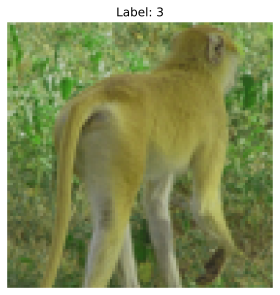

In [12]:
train_obs = train_dataset.__getitem__(2)

# De-normalize for visualization
inv_normalize = transforms.Normalize(
    mean=-train_mean/train_std,
    std=1/train_std
)

# Plot single observation
plt.imshow(inv_normalize(train_obs[0]).permute(1, 2, 0).numpy())
plt.title(f"Label: {train_obs[1]}")
plt.axis('off')

### Define Dataloaders

In [13]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

<a id="section-9"></a>
### **Section 9: Fine-tuning ConvNet on STL-10 (14 points)**

In this section, you will load the pre-trained parameters of the ConvNet (trained on CIFAR-100) and modify the output layer to adapt it to the new dataset containing 5 classes. You can either first load the pre-trained parameters and then modify the output layer, or change the output layer before loading the matched pre-trained parameters. Once modified, you will train the model and document the settings of hyperparameters, accuracy, and learning curve. Additionally, visualize both the training loss and accuracy to assess the learning process. To gain a deeper understanding of the feature learning process, consider using techniques like [**t-sne**](https://lvdmaaten.github.io/tsne/) for feature space visualization.

In [16]:
model = ConvNetNew(num_classes=5, p_drop=0.3)

train_obs, train_label = train_dataset.__getitem__(2)

_, c, h, w = model.features(train_obs.unsqueeze(0)).shape

print(f"Feature map shape after conv layers: [1, {c}, {h}, {w}]")
print(f"Total features before classifier: {c*h*w}")

Feature map shape after conv layers: [1, 120, 17, 17]
Total features before classifier: 34680


In [ ]:
# YOUR CODE HERE
weight_path = './cifar_pretrained_path.pth'

model = ConvNetNew(p_drop=0.3)

if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path))

# Freeze Conv Layers
# for param in model.features.parameters():
#     param.requires_grad = False

# Create two bottleneck layers
bottlneck_1 = (c * h * w) // 4
bottlneck_2 = bottlneck_1 // 4

# Modify classifier to match 5 classes
model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(c * h * w, bottlneck_1),
    nn.ReLU(),
    nn.Linear(bottlneck_1, bottlneck_2),
    nn.ReLU(),
    nn.Linear(bottlneck_2, 5)
)

if torch.cuda.is_available():
    model = model.cuda()
    device = torch.device("cuda")
else:
    print("CUDA not available, check your setup.")
    device = torch.device("cpu")

out = train(
    model,
    train_dataloader,
    test_dataloader,
    nn.CrossEntropyLoss(),
    torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4),
    epochs=20,
    device=device
)

[TB] Logging to: /home/doterog/repos/cv-class/Computer_vision_group66/runs/CIFAR100/ConvNetNew/2025-10-13


In [ ]:
# === Problem 2 (simplified): add 2 layers to TwoLayerNet & ConvNet and evaluate ===
import torch, torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _num_classes(ds):
    return len(getattr(ds, "classes", [])) or len(set(getattr(ds, "targets", []))) or 100

num_classes = _num_classes(getattr(train_loader, "dataset", None))

# Define + variants only if not already present in your notebook
try:
    TwoLayerNetPlus
except NameError:
    class TwoLayerNetPlus(nn.Module):
        def __init__(self, input_size=3*32*32, h1=512, h2=256, num_classes=100, p=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Flatten(),
                nn.Linear(input_size, h1), nn.BatchNorm1d(h1), nn.ReLU(True), nn.Dropout(p),   # +1 layer
                nn.Linear(h1, h2),         nn.BatchNorm1d(h2), nn.ReLU(True), nn.Dropout(p),   # +1 layer
                nn.Linear(h2, num_classes),
            )
        def forward(self, x): return self.net(x)

try:
    ConvNetPlus
except NameError:
    class ConvNetPlus(nn.Module):
        def __init__(self, num_classes=100, p=0.3):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 32→16
                nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 16→8
                nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),  # +1 layer
                nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), # +1 layer
                nn.MaxPool2d(2), nn.Dropout2d(p),                      # 8→4
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128*4*4, 256), nn.ReLU(True), nn.Dropout(p),  # extra FC head
                nn.Linear(256, num_classes),
            )
        def forward(self, x): return self.classifier(self.features(x))

def run_once(model, opt="adamw", lr=1e-3, wd=1e-4, epochs=10):
    if opt == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.CrossEntropyLoss()
    out = train(model, train_loader, test_loader, crit, optimizer, epochs=epochs, device=device)
    te_accs = out[-1] if len(out) == 5 else out[3]   # support both return signatures
    return te_accs[-1], max(te_accs)

# Build, train, report
tlnp = TwoLayerNetPlus(num_classes=num_classes).to(device)
cnnp = ConvNetPlus(num_classes=num_classes).to(device)

tlnp_final, tlnp_best = run_once(tlnp,  opt="adamw", lr=1e-3, wd=1e-4, epochs=10)
cnnp_final, cnnp_best = run_once(cnnp,  opt="sgd",   lr=0.05, wd=5e-4, epochs=10)

print(f"[TwoLayerNetPlus] final={tlnp_final:.2f}% | best={tlnp_best:.2f}%")
print(f"[ConvNetPlus]    final={cnnp_final:.2f}% | best={cnnp_best:.2f}%")


NameError: name 'train_loader' is not defined

<a id="section-10"></a>
### **Section 10: Bonus Challenge (optional)**

Try to achieve the highest possible accuracy on the test dataset (5 classes from STL-10) by adjusting hyperparameters, modifying architectures, or applying techniques like data augmentation. The top-performing teams will earn bonus points that can significantly boost their final lab grade, even allowing it to exceed 10 (up to 11):

- **1st place:** +1.0 to the final grade of the final lab
- **2nd place:** +0.8 to the final grade of the final lab
- **3rd place:** +0.6 to the final grade of the final lab
- **4th place:** +0.4 to the final grade of the final lab
- **5th place:** +0.2 to the final grade of the final lab

**Hint:** You may use techniques like data augmentation, freezing early layers, modifying architecture, or optimizing hyperparameters. Only data from CIFAR-100 and STL-10 can be used, and you cannot add more than 3 additional convolutional layers.

In [22]:
# YOUR CODE HERE

<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |

### - End of Notebook -